In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import copy

from torchvision import models, transforms
from torchvision.models import EfficientNet_B0_Weights

from PIL import Image
import pandas as pd
from pathlib import Path
from tqdm import tqdm

from google.colab import drive

drive.mount("/content/drive")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cuda
NVIDIA L4


In [2]:
SPLIT_DIR = Path("/content/drive/MyDrive/bachelor_thesis_data/splits")

train_df_200kimg = pd.read_csv(SPLIT_DIR / "train_gan_200kimg_double.csv")
train_df_500kimg = pd.read_csv(SPLIT_DIR / "train_gan_500kimg_double.csv")
val_df = pd.read_csv(SPLIT_DIR / "val_split.csv")
test_df = pd.read_csv(SPLIT_DIR / "test_split.csv")

print(train_df_200kimg.head())
print(train_df_200kimg["label"].value_counts())

print(train_df_500kimg.head())
print(train_df_500kimg["label"].value_counts())

        isic_id   lesion_id                 diagnosis_3  binary_label  label  \
0  ISIC_0024307  IL_6125741                       Nevus  Non-Melanoma      0   
1  ISIC_0024308  IL_3692653                       Nevus  Non-Melanoma      0   
2  ISIC_0024309  IL_0959663                       Nevus  Non-Melanoma      0   
3  ISIC_0024310  IL_8194852               Melanoma, NOS      Melanoma      1   
4  ISIC_0024312  IL_3471258  Pigmented benign keratosis  Non-Melanoma      0   

                                          image_path  
0  /content/drive/MyDrive/bachelor_thesis_data/HA...  
1  /content/drive/MyDrive/bachelor_thesis_data/HA...  
2  /content/drive/MyDrive/bachelor_thesis_data/HA...  
3  /content/drive/MyDrive/bachelor_thesis_data/HA...  
4  /content/drive/MyDrive/bachelor_thesis_data/HA...  
label
0    7261
1    1886
Name: count, dtype: int64
        isic_id   lesion_id                 diagnosis_3  binary_label  label  \
0  ISIC_0024307  IL_6125741                       Nevus  

In [3]:
weights = EfficientNet_B0_Weights.DEFAULT

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
import os
import numpy as np
import random

SEED = 42

def set_seed(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    torch.use_deterministic_algorithms(True, warn_only=True)

set_seed(SEED)

print(f"Random seed: {SEED}")

Random seed: 42


In [5]:
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


In [6]:
!mkdir -p /content/HAM10000_images
!rsync -ah --info=progress2 /content/drive/MyDrive/bachelor_thesis_data/HAM10000_ISIC/images/ /content/HAM10000_images/

        326.28M 100%   34.76kB/s    2:32:44 (xfr#11721, to-chk=0/11722)   


In [7]:
!find /content/HAM10000_images -type f | wc -l
!du -sh /content/HAM10000_images

11721
335M	/content/HAM10000_images


In [ ]:
from pathlib import Path

old_real_path = "/content/drive/MyDrive/bachelor_thesis_data/HAM10000_ISIC/images"
new_real_path = "/content/HAM10000_images"

val_df["image_path"] = val_df["image_path"].str.replace(
    old_real_path,
    new_real_path,
    regex=False
)

test_df["image_path"] = test_df["image_path"].str.replace(
    old_real_path,
    new_real_path,
    regex=False
)

In [ ]:
import shutil
from pathlib import Path

LOCAL_GAN_200_DIR = Path("/content/gan_200kimg_images")
LOCAL_GAN_500_DIR = Path("/content/gan_500kimg_images")

LOCAL_GAN_200_DIR.mkdir(parents=True, exist_ok=True)
LOCAL_GAN_500_DIR.mkdir(parents=True, exist_ok=True)

def copy_synthetic_images(
    train_df: pd.DataFrame,
    local_directory: Path
):
    synthetic_df = train_df[
        train_df["isic_id"].astype(str).str.startswith("synthetic_")
    ]

    print(f"Synthetic rows found: {len(synthetic_df)}")

    for source_path in tqdm(
        synthetic_df["image_path"],
        desc=f"Copying to {local_directory.name}"
    ):
        source_path = Path(source_path)
        destination_path = local_directory / source_path.name

        if not destination_path.exists():
            shutil.copy2(source_path, destination_path)

    copied_count = len(list(local_directory.glob("*.png")))
    print(f"Images available locally: {copied_count}")

copy_synthetic_images(
    train_df_200kimg,
    LOCAL_GAN_200_DIR
)

copy_synthetic_images(
    train_df_500kimg,
    LOCAL_GAN_500_DIR
)

Synthetic rows found: 943


Copying to gan_200kimg_images:   0%|          | 0/943 [00:00<?, ?it/s]

Copying to gan_200kimg_images:   0%|          | 0/943 [00:25<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
def convert_to_local_paths(
    dataframe: pd.DataFrame,
    local_synthetic_directory: Path
):
    dataframe = dataframe.copy()

    synthetic_mask = (
        dataframe["isic_id"]
        .astype(str)
        .str.startswith("synthetic_")
    )

    dataframe.loc[synthetic_mask, "image_path"] = (
        dataframe.loc[synthetic_mask, "image_path"]
        .apply(
            lambda path:
            str(local_synthetic_directory / Path(path).name)
        )
    )

    dataframe.loc[~synthetic_mask, "image_path"] = (
        dataframe.loc[~synthetic_mask, "image_path"]
        .apply(
            lambda path:
            str(Path("/content/HAM10000_images") / Path(path).name)
        )
    )

    return dataframe

train_df_200kimg = convert_to_local_paths(
    train_df_200kimg,
    LOCAL_GAN_200_DIR
)

train_df_500kimg = convert_to_local_paths(
    train_df_500kimg,
    LOCAL_GAN_500_DIR
)

In [29]:
def check_paths(name, dataframe):
    exists = dataframe["image_path"].apply(
        lambda path: Path(path).exists()
    )

    print(f"{name}:")
    print(f"  Total rows: {len(dataframe)}")
    print(f"  Existing files: {exists.sum()}")
    print(f"  Missing files: {(~exists).sum()}")

    if (~exists).any():
        print("\nExample missing paths:")
        print(
            dataframe.loc[~exists, "image_path"].head()
        )

check_paths("200-kimg training set", train_df_200kimg)
check_paths("500-kimg training set", train_df_500kimg)
check_paths("Validation set", val_df)
check_paths("Test set", test_df)

200-kimg training set:
  Total rows: 9147
  Existing files: 9147
  Missing files: 0
500-kimg training set:
  Total rows: 9147
  Existing files: 9147
  Missing files: 0
Validation set:
  Total rows: 1742
  Existing files: 1742
  Missing files: 0
Test set:
  Total rows: 1774
  Existing files: 1774
  Missing files: 0


In [6]:
class MelanomaDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image_path = row["image_path"]
        label = row["label"]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(label, dtype=torch.float32)

        return image, label

In [7]:
BATCH_SIZE = 32

generator_200 = torch.Generator()
generator_200.manual_seed(SEED)

generator_500 = torch.Generator()
generator_500.manual_seed(SEED)

train_200kimg_dataset = MelanomaDataset(
    train_df_200kimg,
    transform=train_transform
)

train_500kimg_dataset = MelanomaDataset(
    train_df_500kimg,
    transform=train_transform
)

val_dataset = MelanomaDataset(
    val_df,
    transform=val_test_transform
)

test_dataset = MelanomaDataset(
    test_df,
    transform=val_test_transform
)

train_loader_200kimg = DataLoader(
    train_200kimg_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    worker_init_fn=seed_worker,
    generator=generator_200
)

train_loader_500kimg = DataLoader(
    train_500kimg_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    worker_init_fn=seed_worker,
    generator=generator_500
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    worker_init_fn=seed_worker
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    worker_init_fn=seed_worker
)

In [8]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for images, labels in tqdm(dataloader):
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(dataloader.dataset)
    return epoch_loss

def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader):
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.sigmoid(outputs)

            running_loss += loss.item() * images.size(0)

            all_labels.extend(labels.cpu().numpy().flatten())
            all_probs.extend(probs.cpu().numpy().flatten())

    epoch_loss = running_loss / len(dataloader.dataset)

    return epoch_loss, all_labels, all_probs

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

set_seed(SEED)
generator_200.manual_seed(SEED)

weights = EfficientNet_B0_Weights.DEFAULT

model = models.efficientnet_b0(weights=weights)

in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 1)

model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

def calculate_metrics(labels, probs, threshold=0.5):
    preds = [1 if p >= threshold else 0 for p in probs]

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "roc_auc": roc_auc_score(labels, probs)
    }

EPOCHS = 20

history = []
best_val_f1 = -1.0
best_model_state = None
best_epoch = 0

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")

    train_loss = train_one_epoch(
        model=model,
        dataloader=train_loader_200kimg,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    val_loss, val_labels, val_probs = evaluate(
        model=model,
        dataloader=val_loader,
        criterion=criterion,
        device=device
    )

    val_metrics = calculate_metrics(
        labels=val_labels,
        probs=val_probs,
        threshold=0.5
    )

    epoch_results = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "accuracy": val_metrics["accuracy"],
        "precision": val_metrics["precision"],
        "recall": val_metrics["recall"],
        "f1": val_metrics["f1"],
        "roc_auc": val_metrics["roc_auc"]
    }

    history.append(epoch_results)

    print(f"Train loss: {train_loss:.4f}")
    print(f"Val loss: {val_loss:.4f}")
    print(f"Accuracy: {val_metrics['accuracy']:.4f}")
    print(f"Precision: {val_metrics['precision']:.4f}")
    print(f"Recall: {val_metrics['recall']:.4f}")
    print(f"F1-score: {val_metrics['f1']:.4f}")
    print(f"ROC-AUC: {val_metrics['roc_auc']:.4f}")

    if val_metrics["f1"] > best_val_f1:
        best_val_f1 = val_metrics["f1"]
        best_epoch = epoch + 1
        best_model_state = copy.deepcopy(model.state_dict())
        print("New best model saved.")

history_df = pd.DataFrame(history)

model.load_state_dict(best_model_state)

print("\nTraining finished.")
print(f"Best epoch: {best_epoch}")
print(f"Best validation F1-score: {best_val_f1:.4f}")

CHECKPOINT_DIR = Path("/content/drive/MyDrive/bachelor_thesis_data/checkpoints")
RESULTS_DIR = Path("/content/drive/MyDrive/bachelor_thesis_data/results/tables")

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

torch.save(
    best_model_state,
    CHECKPOINT_DIR / "gan_augmentation_double_200kimg.pth"
)

history_df.to_csv(
    RESULTS_DIR / "gan_augmentation_double_200kimg_training_history.csv",
    index=False
)

print("\nSaved:")
print(CHECKPOINT_DIR / "gan_augmentation_double_200kimg.pth")
print(RESULTS_DIR / "gan_augmentation_double_200kimg_training_history.csv")

best_val_loss, best_val_labels, best_val_probs = evaluate(
    model=model,
    dataloader=val_loader,
    criterion=criterion,
    device=device
)

best_val_metrics = calculate_metrics(
    labels=best_val_labels,
    probs=best_val_probs,
    threshold=0.5
)

best_val_preds = [1 if p >= 0.5 else 0 for p in best_val_probs]
best_cm = confusion_matrix(best_val_labels, best_val_preds)

print("\nBest model validation results:")
print(f"Val loss: {best_val_loss:.4f}")
print(f"Accuracy: {best_val_metrics['accuracy']:.4f}")
print(f"Precision: {best_val_metrics['precision']:.4f}")
print(f"Recall: {best_val_metrics['recall']:.4f}")
print(f"F1-score: {best_val_metrics['f1']:.4f}")
print(f"ROC-AUC: {best_val_metrics['roc_auc']:.4f}")
print("Confusion matrix:")
print(best_cm)

history_df

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 210MB/s]



Epoch 1/20


100%|██████████| 55/55 [00:04<00:00, 11.86it/s]


Train loss: 0.3034
Val loss: 0.2397
Accuracy: 0.8921
Precision: 0.5114
Recall: 0.5803
F1-score: 0.5437
ROC-AUC: 0.9024
New best model saved.

Epoch 2/20


...

100%|██████████| 55/55 [00:04<00:00, 12.47it/s]


Train loss: 0.0128
Val loss: 0.4882
Accuracy: 0.9076
Precision: 0.6039
Recall: 0.4819
F1-score: 0.5360
ROC-AUC: 0.8948

Training finished.
Best epoch: 6
Best validation F1-score: 0.5980

Saved:
/content/drive/MyDrive/bachelor_thesis_data/checkpoints/gan_augmentation_double_200kimg.pth
/content/drive/MyDrive/bachelor_thesis_data/results/tables/gan_augmentation_double_200kimg_training_history.csv


100%|██████████| 55/55 [00:04<00:00, 12.33it/s]


Best model validation results:
Val loss: 0.3120
Accuracy: 0.9059
Precision: 0.5674
Recall: 0.6321
F1-score: 0.5980
ROC-AUC: 0.9053
Confusion matrix:
[[1456   93]
 [  71  122]]


,epoch,train_loss,val_loss,accuracy,precision,recall,f1,roc_auc
0,1,0.303390,0.239671,0.892078,0.511416,0.580311,0.543689,0.902384
1,2,0.169114,0.228401,0.907003,0.592814,0.512953,0.550000,0.900109
2,3,0.104285,0.275536,0.906429,0.617188,0.409326,0.492212,0.876240
3,4,0.067932,0.261640,0.907003,0.576355,0.606218,0.590909,0.910853
4,5,0.043141,0.298189,0.907577,0.587912,0.554404,0.570667,0.897223
5,6,0.040747,0.311973,0.905855,0.567442,0.632124,0.598039,0.905267
6,7,0.031465,0.352737,0.898393,0.536036,0.616580,0.573494,0.900621
7,8,0.022535,0.395773,0.904133,0.584416,0.466321,0.518732,0.882371
8,9,0.020292,0.382669,0.911022,0.611765,0.538860,0.573003,0.881468
9,10,0.018421,0.414038,0.898967,0.538813,0.611399,0.572816,0.897196


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# ----------------------------
# Recreate model from scratch
# ----------------------------

set_seed(SEED)
generator_500.manual_seed(SEED)

weights = EfficientNet_B0_Weights.DEFAULT

model = models.efficientnet_b0(weights=weights)

in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 1)

model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

def calculate_metrics(labels, probs, threshold=0.5):
    preds = [1 if p >= threshold else 0 for p in probs]

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "roc_auc": roc_auc_score(labels, probs)
    }

EPOCHS = 20

history = []
best_val_f1 = -1.0
best_model_state = None
best_epoch = 0

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")

    train_loss = train_one_epoch(
        model=model,
        dataloader=train_loader_500kimg,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    val_loss, val_labels, val_probs = evaluate(
        model=model,
        dataloader=val_loader,
        criterion=criterion,
        device=device
    )

    val_metrics = calculate_metrics(
        labels=val_labels,
        probs=val_probs,
        threshold=0.5
    )

    epoch_results = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "accuracy": val_metrics["accuracy"],
        "precision": val_metrics["precision"],
        "recall": val_metrics["recall"],
        "f1": val_metrics["f1"],
        "roc_auc": val_metrics["roc_auc"]
    }

    history.append(epoch_results)

    print(f"Train loss: {train_loss:.4f}")
    print(f"Val loss: {val_loss:.4f}")
    print(f"Accuracy: {val_metrics['accuracy']:.4f}")
    print(f"Precision: {val_metrics['precision']:.4f}")
    print(f"Recall: {val_metrics['recall']:.4f}")
    print(f"F1-score: {val_metrics['f1']:.4f}")
    print(f"ROC-AUC: {val_metrics['roc_auc']:.4f}")

    if val_metrics["f1"] > best_val_f1:
        best_val_f1 = val_metrics["f1"]
        best_epoch = epoch + 1
        best_model_state = copy.deepcopy(model.state_dict())
        print("New best model saved.")

history_df = pd.DataFrame(history)

model.load_state_dict(best_model_state)

print("\nTraining finished.")
print(f"Best epoch: {best_epoch}")
print(f"Best validation F1-score: {best_val_f1:.4f}")

CHECKPOINT_DIR = Path("/content/drive/MyDrive/bachelor_thesis_data/checkpoints")
RESULTS_DIR = Path("/content/drive/MyDrive/bachelor_thesis_data/results/tables")

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

torch.save(
    best_model_state,
    CHECKPOINT_DIR / "gan_augmentation_double_500kimg.pth"
)

history_df.to_csv(
    RESULTS_DIR / "gan_augmentation_double_500kimg_training_history.csv",
    index=False
)

print("\nSaved:")
print(CHECKPOINT_DIR / "gan_augmentation_double_500kimg.pth")
print(RESULTS_DIR / "gan_augmentation_double_500kimg_training_history.csv")

best_val_loss, best_val_labels, best_val_probs = evaluate(
    model=model,
    dataloader=val_loader,
    criterion=criterion,
    device=device
)

best_val_metrics = calculate_metrics(
    labels=best_val_labels,
    probs=best_val_probs,
    threshold=0.5
)

best_val_preds = [1 if p >= 0.5 else 0 for p in best_val_probs]
best_cm = confusion_matrix(best_val_labels, best_val_preds)

print("\nBest model validation results:")
print(f"Val loss: {best_val_loss:.4f}")
print(f"Accuracy: {best_val_metrics['accuracy']:.4f}")
print(f"Precision: {best_val_metrics['precision']:.4f}")
print(f"Recall: {best_val_metrics['recall']:.4f}")
print(f"F1-score: {best_val_metrics['f1']:.4f}")
print(f"ROC-AUC: {best_val_metrics['roc_auc']:.4f}")
print("Confusion matrix:")
print(best_cm)

history_df


Epoch 1/20


100%|██████████| 55/55 [00:04<00:00, 12.67it/s]


Train loss: 0.3035
Val loss: 0.2338
Accuracy: 0.9001
Precision: 0.5497
Recall: 0.5440
F1-score: 0.5469
ROC-AUC: 0.9012
New best model saved.

Epoch 2/20


100%|██████████| 55/55 [00:04<00:00, 12.64it/s]


Train loss: 0.1674
Val loss: 0.2276
Accuracy: 0.9047
Precision: 0.5789
Recall: 0.5130
F1-score: 0.5440
ROC-AUC: 0.9035

Epoch 3/20


...

100%|██████████| 55/55 [00:04<00:00, 12.78it/s]


Train loss: 0.0122
Val loss: 0.4434
Accuracy: 0.9173
Precision: 0.6738
Recall: 0.4922
F1-score: 0.5689
ROC-AUC: 0.8953

Training finished.
Best epoch: 16
Best validation F1-score: 0.6220

Saved:
/content/drive/MyDrive/bachelor_thesis_data/checkpoints/gan_augmentation_double_500kimg.pth
/content/drive/MyDrive/bachelor_thesis_data/results/tables/gan_augmentation_double_500kimg_training_history.csv


100%|██████████| 55/55 [00:04<00:00, 12.82it/s]


Best model validation results:
Val loss: 0.3862
Accuracy: 0.9191
Precision: 0.6444
Recall: 0.6010
F1-score: 0.6220
ROC-AUC: 0.9010
Confusion matrix:
[[1485   64]
 [  77  116]]


,epoch,train_loss,val_loss,accuracy,precision,recall,f1,roc_auc
0,1,0.303529,0.233806,0.900115,0.549738,0.544041,0.546875,0.901223
1,2,0.167355,0.227628,0.904707,0.578947,0.512953,0.543956,0.903454
2,3,0.105152,0.259678,0.908726,0.626866,0.435233,0.513761,0.884920
3,4,0.065762,0.263390,0.905281,0.567961,0.606218,0.586466,0.910542
4,5,0.045394,0.304710,0.894374,0.519824,0.611399,0.561905,0.900153
5,6,0.038577,0.333051,0.906429,0.572816,0.611399,0.591479,0.891255
6,7,0.032226,0.327663,0.907003,0.584699,0.554404,0.569149,0.902314
7,8,0.023694,0.364543,0.913318,0.656716,0.455959,0.538226,0.887251
8,9,0.023075,0.360605,0.912744,0.610811,0.585492,0.597884,0.894182
9,10,0.018953,0.377269,0.910448,0.627586,0.471503,0.538462,0.893209


In [ ]:
from torchvision import models
from torchvision.models import EfficientNet_B0_Weights
import torch.nn as nn
import torch
import pandas as pd
from pathlib import Path

CHECKPOINT_PATH = Path(
    "/content/drive/MyDrive/bachelor_thesis_data/checkpoints/"
    "gan_augmentation_double_500kimg.pth"
)

HISTORY_PATH = Path(
    "/content/drive/MyDrive/bachelor_thesis_data/results/tables/"
    "gan_augmentation_double_500kimg_training_history.csv"
)

weights = EfficientNet_B0_Weights.DEFAULT
model = models.efficientnet_b0(weights=weights)

in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 1)

model = model.to(device)

model.load_state_dict(
    torch.load(
        CHECKPOINT_PATH,
        map_location=device,
        weights_only=True
    )
)

model.eval()

history_500 = pd.read_csv(HISTORY_PATH)
best_row = history_500.loc[history_500["f1"].idxmax()]
best_epoch = int(best_row["epoch"])

criterion = nn.BCEWithLogitsLoss()

print("Loaded best 500-kimg classifier checkpoint.")
print("Best epoch:", best_epoch)

Loaded best 500-kimg classifier checkpoint.
Best epoch: 16


In [9]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from pathlib import Path
from torchvision import models

model = models.efficientnet_b0(weights=None)

in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 1)

model = model.to(device)

CHECKPOINT_PATH = Path(
    "/content/drive/MyDrive/bachelor_thesis_data/checkpoints/"
    "gan_augmentation_double_500kimg.pth"
)

best_model_state = torch.load(
    CHECKPOINT_PATH,
    map_location=device,
    weights_only=True
)

model.load_state_dict(best_model_state)
model = model.to(device)
model.eval()

print(f"Loaded best checkpoint: {CHECKPOINT_PATH}")

criterion = nn.BCEWithLogitsLoss()

test_loss, test_labels, test_probs = evaluate(
    model=model,
    dataloader=test_loader,
    criterion=criterion,
    device=device
)

test_preds = [
    1 if probability >= 0.5 else 0
    for probability in test_probs
]

test_accuracy = accuracy_score(
    test_labels,
    test_preds
)

test_precision = precision_score(
    test_labels,
    test_preds,
    zero_division=0
)

test_recall = recall_score(
    test_labels,
    test_preds,
    zero_division=0
)

test_f1 = f1_score(
    test_labels,
    test_preds,
    zero_division=0
)

test_roc_auc = roc_auc_score(
    test_labels,
    test_probs
)

test_cm = confusion_matrix(
    test_labels,
    test_preds
)

print("E4 GAN-500 double-melanoma test results:")
print(f"Test loss: {test_loss:.4f}")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1-score: {test_f1:.4f}")
print(f"ROC-AUC: {test_roc_auc:.4f}")
print("Confusion matrix:")
print(test_cm)

'''gan_test_results = pd.DataFrame([{
    "experiment": "E4_GAN500_double_melanoma",
    "gan_checkpoint_kimg": 500,
    "synthetic_melanoma_images": 943,
    "model": "EfficientNet-B0",
    "seed": SEED,
    "best_epoch": best_epoch,
    "threshold": 0.5,
    "test_loss": test_loss,
    "accuracy": test_accuracy,
    "precision": test_precision,
    "recall": test_recall,
    "f1": test_f1,
    "roc_auc": test_roc_auc,
    "true_negatives": int(test_cm[0, 0]),
    "false_positives": int(test_cm[0, 1]),
    "false_negatives": int(test_cm[1, 0]),
    "true_positives": int(test_cm[1, 1])
}])'''

RESULTS_DIR = Path(
    "/content/drive/MyDrive/bachelor_thesis_data/results/tables"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

'''OUTPUT_PATH = (
    RESULTS_DIR /
    "gan_augmentation_double_500kimg_test_results.csv"
)

gan_test_results.to_csv(
    OUTPUT_PATH,
    index=False
)'''

# print("\nSaved:")
# print(OUTPUT_PATH)
# gan_test_results

test_labels_array = np.asarray(test_labels).reshape(-1).astype(int)
test_probs_array = np.asarray(test_probs).reshape(-1).astype(float)
test_preds_array = (test_probs_array >= 0.5).astype(int)

gan_double_test_predictions = pd.DataFrame({
    "y_true": test_labels_array,
    "y_probability": test_probs_array,
    "y_pred_0_5": test_preds_array
})

prediction_path = (
    RESULTS_DIR /
    "gan_augmentation_double_500kimg_test_predictions.csv"
)

gan_double_test_predictions.to_csv(
    prediction_path,
    index=False
)

print(f"Saved predictions to: {prediction_path}")
print(
    f"Number of predictions: "
    f"{len(gan_double_test_predictions)}"
)
print(
    f"Melanoma images: "
    f"{gan_double_test_predictions['y_true'].sum()}"
)
print(
    "Non-melanoma images:",
    (gan_double_test_predictions["y_true"] == 0).sum()
)

gan_double_test_predictions.head()

Loaded best checkpoint: /content/drive/MyDrive/bachelor_thesis_data/checkpoints/gan_augmentation_double_500kimg.pth


100%|██████████| 56/56 [10:24<00:00, 11.15s/it] 


E4 GAN-500 double-melanoma test results:
Test loss: 0.3465
Accuracy: 0.9126
Precision: 0.5389
Recall: 0.5740
F1-score: 0.5559
ROC-AUC: 0.8951
Confusion matrix:
[[1522   83]
 [  72   97]]
Saved predictions to: /content/drive/MyDrive/bachelor_thesis_data/results/tables/gan_augmentation_double_500kimg_test_predictions.csv
Number of predictions: 1774
Melanoma images: 169
Non-melanoma images: 1605


,y_true,y_probability,y_pred_0_5
0,0,2.233352e-05,0
1,0,5.635145e-06,0
2,0,1.535283e-05,0
3,0,1.913530e-06,0
4,0,8.089125e-08,0



GAN 200 kimg


,epoch,train_loss,val_loss,accuracy,precision,recall,f1,roc_auc
0,1,0.303390,0.239671,0.892078,0.511416,0.580311,0.543689,0.902384
1,2,0.169114,0.228401,0.907003,0.592814,0.512953,0.550000,0.900109
2,3,0.104285,0.275536,0.906429,0.617188,0.409326,0.492212,0.876240
3,4,0.067932,0.261640,0.907003,0.576355,0.606218,0.590909,0.910853
4,5,0.043141,0.298189,0.907577,0.587912,0.554404,0.570667,0.897223
5,6,0.040747,0.311973,0.905855,0.567442,0.632124,0.598039,0.905267
6,7,0.031465,0.352737,0.898393,0.536036,0.616580,0.573494,0.900621
7,8,0.022535,0.395773,0.904133,0.584416,0.466321,0.518732,0.882371
8,9,0.020292,0.382669,0.911022,0.611765,0.538860,0.573003,0.881468
9,10,0.018421,0.414038,0.898967,0.538813,0.611399,0.572816,0.897196


Lowest validation loss:
Epoch 2, val_loss = 0.2284

Highest validation F1-score:
Epoch 6, F1 = 0.5980


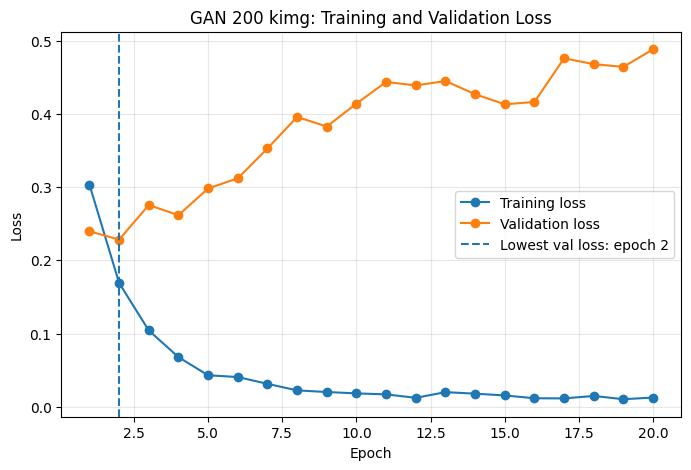

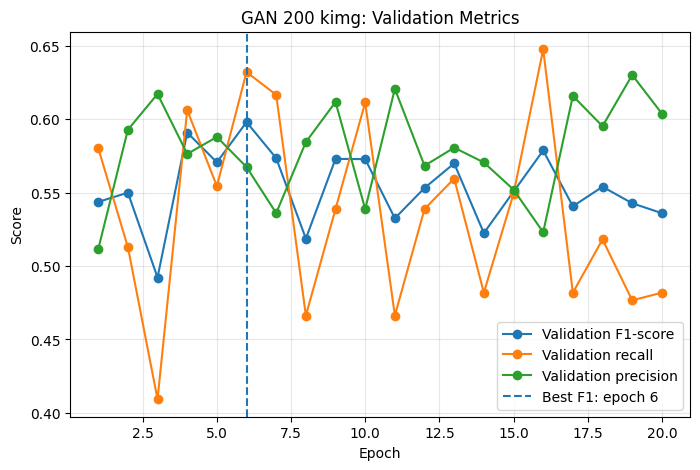


GAN 500 kimg


,epoch,train_loss,val_loss,accuracy,precision,recall,f1,roc_auc
0,1,0.303529,0.233806,0.900115,0.549738,0.544041,0.546875,0.901223
1,2,0.167355,0.227628,0.904707,0.578947,0.512953,0.543956,0.903454
2,3,0.105152,0.259678,0.908726,0.626866,0.435233,0.513761,0.884920
3,4,0.065762,0.263390,0.905281,0.567961,0.606218,0.586466,0.910542
4,5,0.045394,0.304710,0.894374,0.519824,0.611399,0.561905,0.900153
5,6,0.038577,0.333051,0.906429,0.572816,0.611399,0.591479,0.891255
6,7,0.032226,0.327663,0.907003,0.584699,0.554404,0.569149,0.902314
7,8,0.023694,0.364543,0.913318,0.656716,0.455959,0.538226,0.887251
8,9,0.023075,0.360605,0.912744,0.610811,0.585492,0.597884,0.894182
9,10,0.018953,0.377269,0.910448,0.627586,0.471503,0.538462,0.893209


Lowest validation loss:
Epoch 2, val_loss = 0.2276

Highest validation F1-score:
Epoch 16, F1 = 0.6220


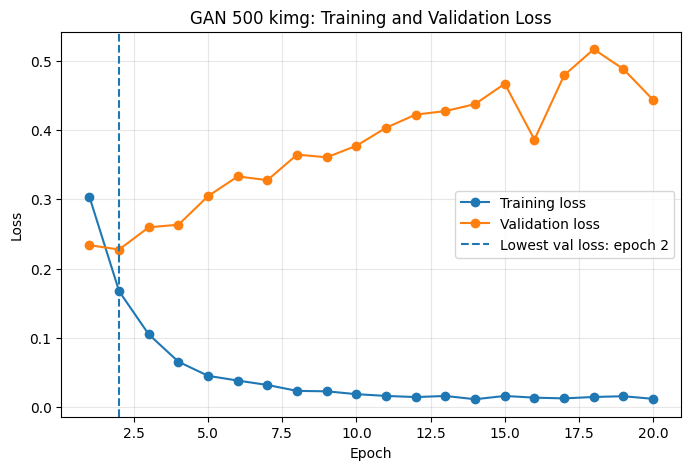

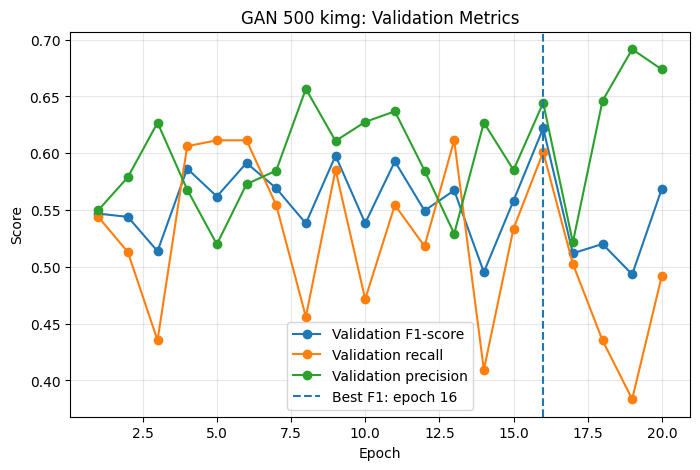

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

HISTORY_FILES = {
    "GAN 200 kimg": Path(
        "/content/drive/MyDrive/bachelor_thesis_data/results/tables/"
        "gan_augmentation_double_200kimg_training_history.csv"
    ),
    "GAN 500 kimg": Path(
        "/content/drive/MyDrive/bachelor_thesis_data/results/tables/"
        "gan_augmentation_double_500kimg_training_history.csv"
    ),
}

FIGURE_DIR = Path(
    "/content/drive/MyDrive/bachelor_thesis_data/results/figures"
)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

for experiment_name, history_path in HISTORY_FILES.items():

    history_df = pd.read_csv(history_path)

    print(f"\n{experiment_name}")
    display(history_df)

    best_val_loss_idx = history_df["val_loss"].idxmin()
    best_val_loss_epoch = int(
        history_df.loc[best_val_loss_idx, "epoch"]
    )
    best_val_loss = float(
        history_df.loc[best_val_loss_idx, "val_loss"]
    )

    best_f1_idx = history_df["f1"].idxmax()
    best_f1_epoch = int(
        history_df.loc[best_f1_idx, "epoch"]
    )
    best_f1 = float(
        history_df.loc[best_f1_idx, "f1"]
    )

    print("Lowest validation loss:")
    print(
        f"Epoch {best_val_loss_epoch}, "
        f"val_loss = {best_val_loss:.4f}"
    )

    print("\nHighest validation F1-score:")
    print(
        f"Epoch {best_f1_epoch}, "
        f"F1 = {best_f1:.4f}"
    )

    filename_prefix = experiment_name.lower().replace(" ", "_")

    plt.figure(figsize=(8, 5))

    plt.plot(
        history_df["epoch"],
        history_df["train_loss"],
        marker="o",
        label="Training loss"
    )

    plt.plot(
        history_df["epoch"],
        history_df["val_loss"],
        marker="o",
        label="Validation loss"
    )

    plt.axvline(
        best_val_loss_epoch,
        linestyle="--",
        label=f"Lowest val loss: epoch {best_val_loss_epoch}"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{experiment_name}: Training and Validation Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.savefig(
        FIGURE_DIR / f"{filename_prefix}_loss_curve.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.figure(figsize=(8, 5))

    plt.plot(
        history_df["epoch"],
        history_df["f1"],
        marker="o",
        label="Validation F1-score"
    )

    plt.plot(
        history_df["epoch"],
        history_df["recall"],
        marker="o",
        label="Validation recall"
    )

    plt.plot(
        history_df["epoch"],
        history_df["precision"],
        marker="o",
        label="Validation precision"
    )

    plt.axvline(
        best_f1_epoch,
        linestyle="--",
        label=f"Best F1: epoch {best_f1_epoch}"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.title(f"{experiment_name}: Validation Metrics")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.savefig(
        FIGURE_DIR / f"{filename_prefix}_validation_metrics.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

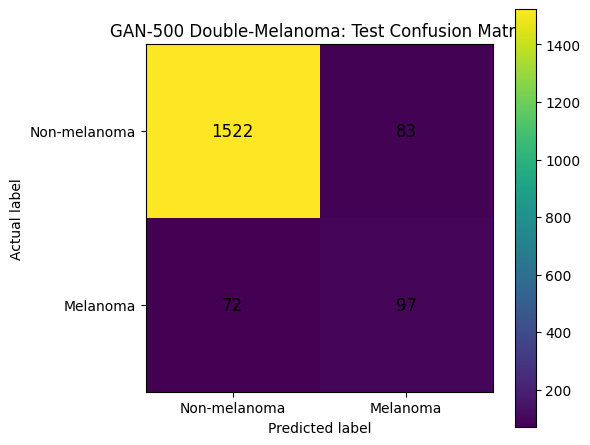

Saved:
/content/drive/MyDrive/bachelor_thesis_data/results/figures/gan_augmentation_double_500kimg_test_confusion_matrix.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

cm = np.asarray(test_cm)

class_names = ["Non-melanoma", "Melanoma"]

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(cm)

ax.set_title("GAN-500 Balanced Training: Test Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("Actual label")

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            int(cm[i, j]),
            ha="center",
            va="center",
            fontsize=12
        )

plt.colorbar(im, ax=ax)
plt.tight_layout()

FIGURE_DIR = Path(
    "/content/drive/MyDrive/bachelor_thesis_data/results/figures"
)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PATH = (
    FIGURE_DIR /
    "gan_augmentation_double_500kimg_test_confusion_matrix.png"
)

plt.savefig(
    OUTPUT_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(OUTPUT_PATH)